In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:

food_orders = pd.read_csv("food_orders_new_delhi.csv")

In [3]:
food_orders.head()

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,47,0
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,23,0
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,15% New User,195,45,0
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,NaN,146,27,0
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50 off Promo,130,50,0


In [4]:
food_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Order ID                1000 non-null   int64 
 1   Customer ID             1000 non-null   object
 2   Restaurant ID           1000 non-null   object
 3   Order Date and Time     1000 non-null   object
 4   Delivery Date and Time  1000 non-null   object
 5   Order Value             1000 non-null   int64 
 6   Delivery Fee            1000 non-null   int64 
 7   Payment Method          1000 non-null   object
 8   Discounts and Offers    815 non-null    object
 9   Commission Fee          1000 non-null   int64 
 10  Payment Processing Fee  1000 non-null   int64 
 11  Refunds/Chargebacks     1000 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 93.9+ KB


In [5]:
# convert date and time columns to datetime
order_datetime = 'Order Date and Time'
del_datetime = 'Delivery Date and Time'
food_orders[order_datetime] = pd.to_datetime(food_orders[order_datetime])
food_orders[del_datetime] = pd.to_datetime(food_orders[del_datetime])


In [8]:

# first, let's create a function to extract numeric values from the 'Discounts and Offers' string
def extract_discount(discount_str):
    if 'off' in discount_str:
        # Fixed amount off
        return float(discount_str.split(' ')[0])
    elif '%' in discount_str:
        # Percentage off
        return float(discount_str.split('%')[0])
    else:
        # No discount
        return 0.0

In [9]:
test = ['5% on App', '10%', '15% New User', '50 off Promo']
out = extract_discount(test[0])
out

5.0

In [10]:
#columns in use
discount_str = 'Discounts and Offers'
order_int = 'Order Value'
#new columns
discount_float = 'Discount Percentage'
discount_amount = 'Discount Amount'

In [11]:
#new column for discount value
food_orders[discount_float] = food_orders[discount_str].apply(lambda x: extract_discount(str(x)))

In [12]:
food_orders[discount_amount] = food_orders.apply(lambda x: (x[order_int]*x[discount_float]*0.01) , axis=1 )

In [13]:
food_orders.head()

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks,Discount Percentage,Discount Amount
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,47,0,5.0,95.70
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,23,0,10.0,98.60
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,15% New User,195,45,0,15.0,140.55
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,NaN,146,27,0,0.0,0.00
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50 off Promo,130,50,0,50.0,996.00


In [14]:
#columns in use
comm_int = 'Commission Fee'
del_int = 'Delivery Fee'
pay_process_int = 'Payment Processing Fee'
#discount_amount = 'Discount Amount'

revenue = 'Revenue'
total_costs = 'Total Costs'
profits = 'Profits'


In [15]:
food_orders[revenue] = food_orders.apply(lambda x: 
                                            (x[comm_int]) , axis=1)
food_orders[total_costs] = food_orders.apply(lambda x: 
                                            (x[del_int]+x[pay_process_int]+x[discount_amount] ) , axis=1)
food_orders[profits] = food_orders.apply(lambda x: 
                                            (x[comm_int]-x[del_int]-x[pay_process_int]-x[discount_amount] ) , axis=1)

In [17]:
# aggregate data to get overall metrics

total_orders = food_orders.shape[0]
total_revenue = food_orders[revenue].sum()
total_costs = food_orders[total_costs].sum()
total_profit = food_orders[profits].sum()

overall_metrics = {
    "Total Orders": total_orders,
    "Total Revenue": total_revenue,
    "Total Costs": total_costs,
    "Total Profit": total_profit
}



TypeError: bar() missing 1 required positional argument: 'height'

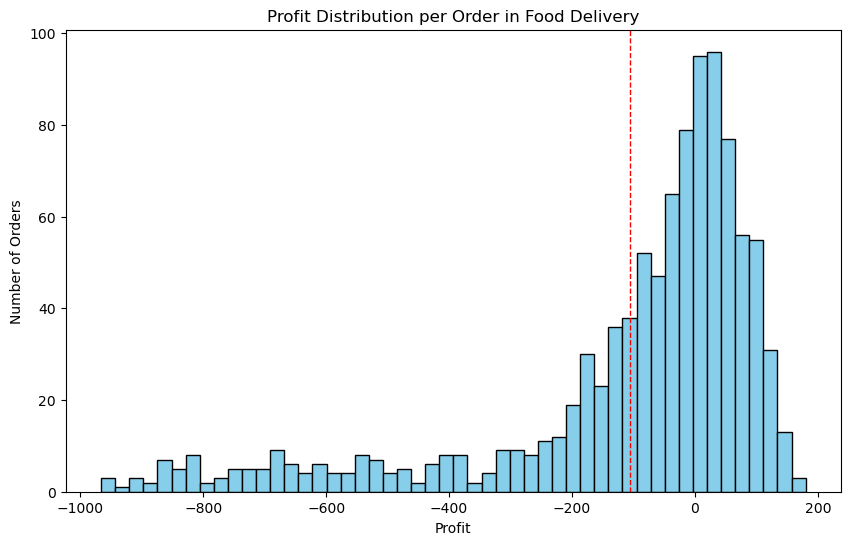

In [19]:
import matplotlib.pyplot as plt

'''
revenue = 'Revenue'
total_costs = 'Total Costs'
profits = 'Profits'
'''
# histogram of profits per order
plt.figure(figsize=(10, 6))
plt.hist(food_orders[profits], bins=50, color='skyblue', edgecolor='black')
plt.title('Profit Distribution per Order in Food Delivery')
plt.xlabel('Profit')
plt.ylabel('Number of Orders')
plt.axvline(food_orders[profits].mean(), color='red', linestyle='dashed', linewidth=1)
plt.show()

In [25]:
costs_breakdown

Delivery Fee               28620.00
Payment Processing Fee     29832.00
Discount Amount           174257.85
dtype: float64

In [56]:
'''#columns in use
comm_int = 'Commission Fee'
del_int = 'Delivery Fee'
pay_process_int = 'Payment Processing Fee'
'''
'''
numericals ---------
total_orders = food_orders.shape[0]
total_revenue = food_orders[revenue].sum()
total_costs = food_orders[total_costs].sum()
total_profit = food_orders[profits].sum()
'''

'''
columns-------------
revenue = 'Revenue'
total_costs = 'Total Costs'
profits = 'Profits'
'''

costs_breakdown_columns = [del_int, pay_process_int, discount_amount]
costs_breakdown = food_orders[costs_breakdown_columns].sum()

result_outlook_columns = [revenue, profits]
result_outlook = [total_revenue, total_profit]




Text(0.5, 1.0, 'Proportion of Total Costs in Food Delivery')

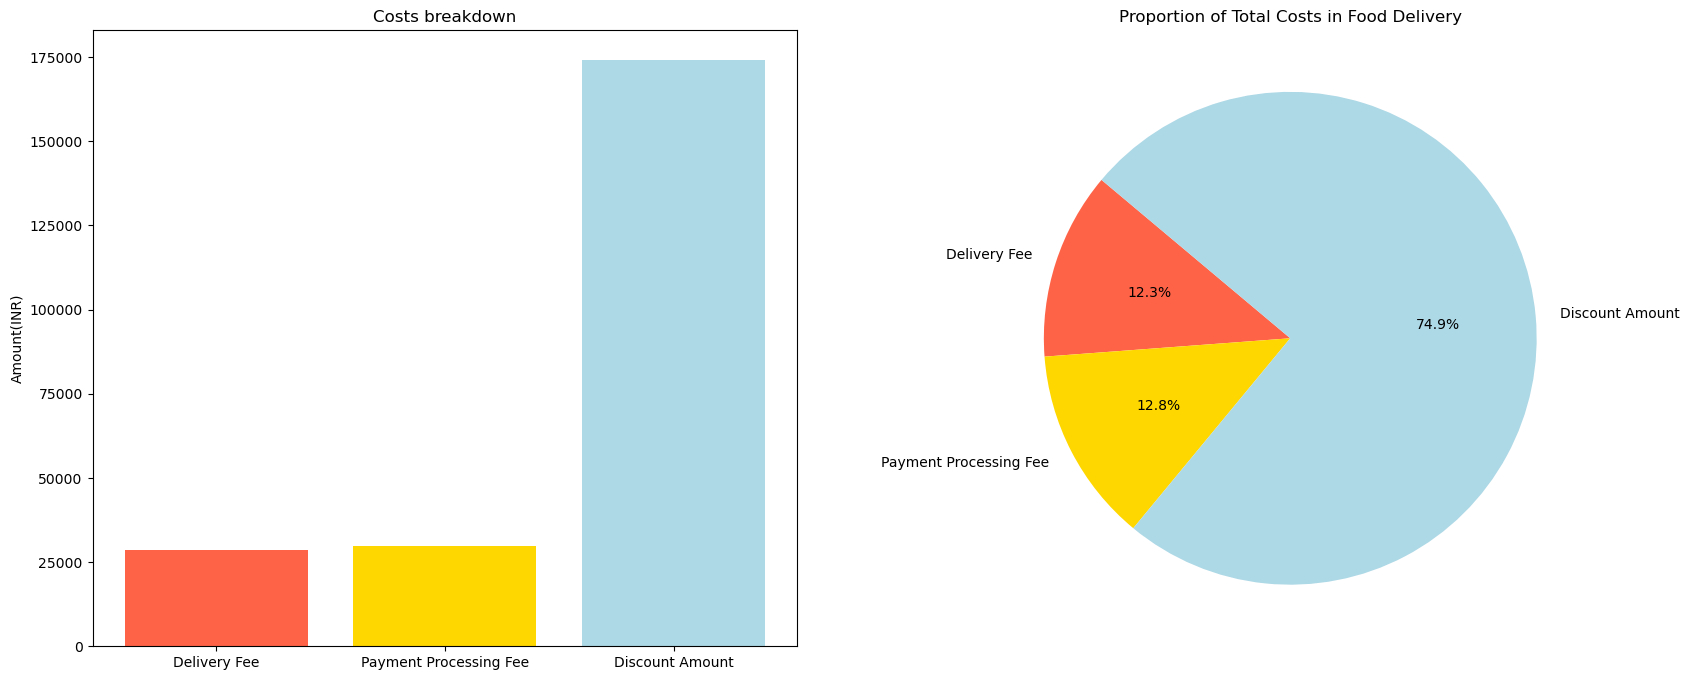

In [59]:
plt.figure(figsize=(20, 8))
#plt.xticks(rotation=10)

plt.subplot(1,2,1)
plt.bar(costs_breakdown_columns, costs_breakdown , color=['tomato', 'gold', 'lightblue'])
plt.title('Costs breakdown')
plt.ylabel('Amount(INR)')

plt.subplot(1,2,2)
plt.pie(costs_breakdown, labels=costs_breakdown_columns, autopct='%1.1f%%', startangle=140, colors=['tomato', 'gold', 'lightblue'])
plt.title('Proportion of Total Costs in Food Delivery')

Text(0, 0.5, 'Amount(INR)')

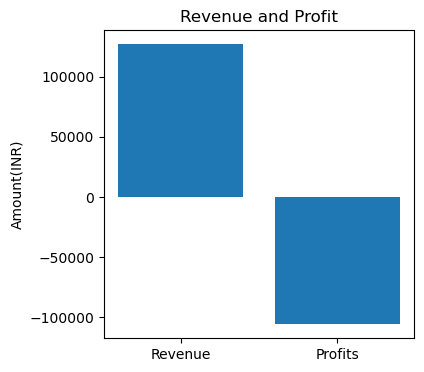

In [60]:
plt.figure(figsize=(4, 4))
#plt.xticks(rotation=10)
plt.bar(result_outlook_columns, result_outlook )
plt.title('Revenue and Profit')
plt.ylabel('Amount(INR)')

In [61]:
#new dataframe for profitable orders
profitable_orders = food_orders[food_orders[profits]>0]

In [79]:

'''#columns in use
#columns in use
discount_str = 'Discounts and Offers'
order_int = 'Order Value'
discount_float = 'Discount Percentage'
discount_amount = 'Discount Amount'
comm_int = 'Commission Fee'
del_int = 'Delivery Fee'
pay_process_int = 'Payment Processing Fee'
'''
comm_ratio = 'Commission ratio'
discount_ratio = 'Discount ratio'
profitable_orders[comm_ratio] = profitable_orders.apply(lambda x: x[comm_int]/x[order_int], axis=1)
profitable_orders[discount_ratio] = profitable_orders.apply(lambda x: x[discount_amount]/x[order_int], axis=1)

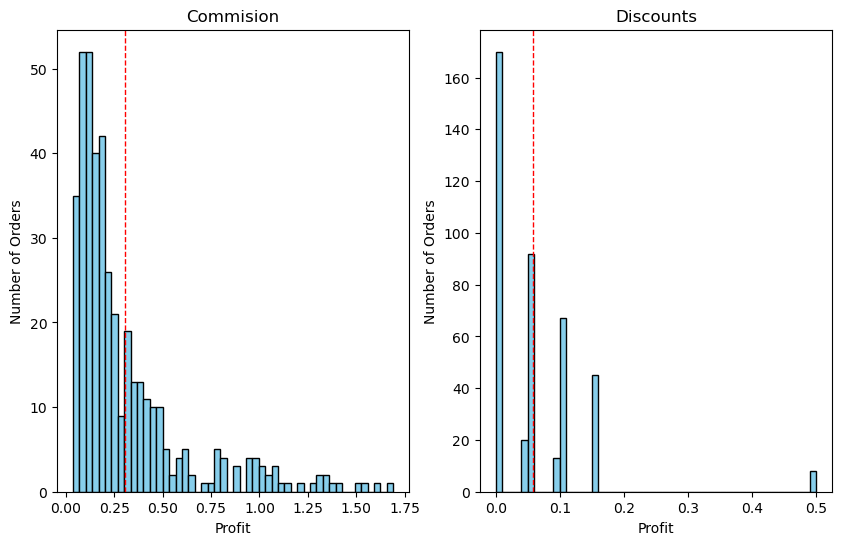

In [87]:
# histogram of profits per order
plt.figure(figsize=(10, 6))

plt.subplot(1,2,1)
plt.hist(profitable_orders[comm_ratio], bins=50, color='skyblue', edgecolor='black')
plt.title('Commision')
plt.xlabel('Profit')
plt.ylabel('Number of Orders')
plt.axvline(profitable_orders[comm_ratio].mean(), color='red', linestyle='dashed', linewidth=1)

plt.subplot(1,2,2)
plt.hist(profitable_orders[discount_ratio], bins=50, color='skyblue', edgecolor='black')
plt.title('Discounts')
plt.xlabel('Profit')
plt.ylabel('Number of Orders')
plt.axvline(profitable_orders[discount_ratio].mean(), color='red', linestyle='dashed', linewidth=1)

In [88]:
advised_comm_ratio = profitable_orders[comm_ratio].mean()
advised_discount_ratio = profitable_orders[discount_ratio].mean()

In [95]:
simulated_comm_fee = 'Simulated Commission Fee'
simulated_discount_amount = 'Simulated Discount Amount'
simulated_total_costs = 'Simulated Total costs'
simulated_profits = 'Simulated Profits'

In [96]:
food_orders[simulated_comm_fee] = food_orders.apply(lambda x: 
                                                    x[order_int]*advised_comm_ratio, axis=1)
food_orders[simulated_discount_amount] = food_orders.apply(lambda x: 
                                                           x[order_int]*advised_discount_ratio, axis=1)


In [97]:
food_orders[simulated_total_costs] = food_orders.apply(lambda x: 
                                                       x[simulated_discount_amount]+
                                                       x[del_int]+
                                                       x[pay_process_int], axis=1)


In [98]:
food_orders[simulated_profits] = food_orders.apply(lambda x: 
                                                   x[simulated_comm_fee]-
                                                   x[simulated_total_costs], axis=1)

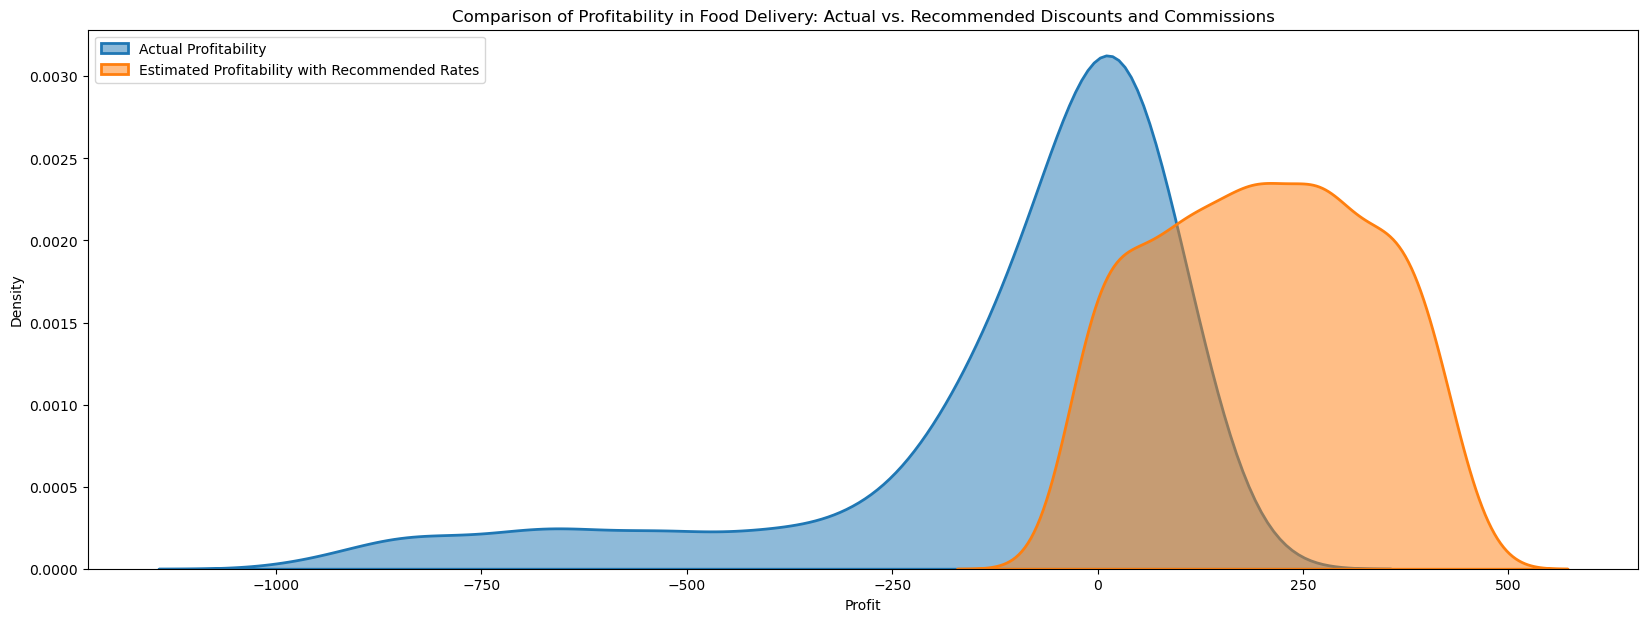

In [101]:

# visualizing the comparison
import seaborn as sns

plt.figure(figsize=(20, 7))

# actual profitability
sns.kdeplot(food_orders[profits], label='Actual Profitability', fill=True, alpha=0.5, linewidth=2)

# simulated profitability
sns.kdeplot(food_orders[simulated_profits], label='Estimated Profitability with Recommended Rates', fill=True, alpha=0.5, linewidth=2)

plt.title('Comparison of Profitability in Food Delivery: Actual vs. Recommended Discounts and Commissions')
plt.xlabel('Profit')
plt.ylabel('Density')
plt.legend(loc='upper left')

In [102]:
food_orders.head()

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,...,Refunds/Chargebacks,Discount Percentage,Discount Amount,Revenue,Total Costs,Profits,Simulated Commission Fee,Simulated Discount Amount,Simulated Total costs,Simulated Profits
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,...,0,5.0,95.70,150,142.70,7.30,583.931468,112.303373,159.303373,424.628094
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,...,0,10.0,98.60,198,161.60,36.40,300.813180,57.853253,120.853253,179.959927
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,15% New User,195,...,0,15.0,140.55,195,215.55,-20.55,285.864047,54.978193,129.978193,155.885854
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,NaN,146,...,0,0.0,0.00,146,77.00,69.00,446.338421,85.841084,162.841084,283.497336
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50 off Promo,130,...,0,50.0,996.00,130,1076.00,-946.00,607.728048,116.880000,196.880000,410.848048
